In [2]:
import pickle

# Replace with your file path
file_path = '/home/dg73/CogPhys/waveforms/rppg/train_fusion/pred.pickle'

# Load the pickle file
with open(file_path, 'rb') as f:
    data = pickle.load(f)

# Print the type and contents
print(f"Type of loaded object: {type(data)}")
print([key for key in data.keys()])
print(type(data['pred']))
print(len(data['pred']), len(data['gt']), len(data['participant_task_chunk_id_list']))
print(data['participant_task_chunk_id_list'])

print(len(data['gt'][0]))


Type of loaded object: <class 'dict'>
['pred', 'gt', 'participant_task_chunk_id_list']
<class 'list'>
588 588 588
[('v14_still', [0, 1, 2]), ('v14_still', [3, 4, 5]), ('v14_still', [6, 7, 8]), ('v14_still', [9, 10, 11]), ('v25_still', [0, 1, 2]), ('v25_still', [3, 4, 5]), ('v25_still', [6, 7, 8]), ('v25_still', [9, 10, 11]), ('v20_number', [0, 1, 2]), ('v20_number', [3, 4, 5]), ('v20_number', [6, 7, 8]), ('v20_number', [9, 10, 11]), ('v18_number', [0, 1, 2]), ('v18_number', [3, 4, 5]), ('v18_number', [6, 7, 8]), ('v18_number', [9, 10, 11]), ('v3_read_rest', [0, 1, 2]), ('v3_read_rest', [3, 4, 5]), ('v3_read_rest', [6, 7, 8]), ('v3_read_rest', [9, 10, 11]), ('v30_pattern_rest', [0, 1, 2]), ('v30_pattern_rest', [3, 4, 5]), ('v30_pattern_rest', [6, 7, 8]), ('v30_pattern_rest', [9, 10, 11]), ('v5_read', [0, 1, 2]), ('v5_read', [3, 4, 5]), ('v5_read', [6, 7, 8]), ('v5_read', [9, 10, 11]), ('v2_pattern', [0, 1, 2]), ('v2_pattern', [3, 4, 5]), ('v2_pattern', [6, 7, 8]), ('v2_pattern', [9, 10,

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

def smooth_signal(signal, window_size=3):
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

# Load the pickle file
file_path = '/home/dg73/CogPhys/waveforms/fusion_pre_nir/pred.pickle'
rgb_file_path = '/home/dg73/CogPhys/waveforms/rgb_cp+/pred.pickle'
#file_path = '/home/dg73/CogPhys/waveforms/nir_cp+_pre/pred.pickle'

with open(file_path, 'rb') as f:
    data = pickle.load(f)
    
with open(rgb_file_path, 'rb') as f:
    rgb_data = pickle.load(f)

# Extract the lists
rgb_pred_list = rgb_data['pred']
pred_list = data['pred']  # List of predicted waveforms
gt_list = data['gt']      # List of ground truth waveforms
participant_info = data['participant_task_chunk_id_list']  # List of participant info

# Sanity check
assert len(pred_list) == len(gt_list) == len(participant_info), "Mismatched lengths"

# Plot each waveform pair
#for i in range(len(pred_list)):
for i in range(150, 175):
    #smooth the fusion waveforms
    if "fusion" in file_path:
        pred = smooth_signal(pred_list[i][:150])
        print("smoothed")
    else:
        pred = pred_list[i][:150]
    rgb_pred = rgb_pred_list[i][:150]
    gt = gt_list[i][:150]
    participant, chunk_ids = participant_info[i]
    
    #if participant =='v22_pattern' and chunk_ids == [0,1,2]:

    plt.figure(figsize=(5, 4))
    plt.plot(pred, label='Fusion Predicted', linestyle='--', linewidth=1)
    plt.plot(rgb_pred, label='RGB Predicted', linestyle='--', linewidth=1)
    plt.plot(gt, label='Ground Truth', alpha=0.7, linewidth=1)
    plt.title(f"Participant: {participant}, Chunk IDs: {chunk_ids}")
    plt.xlabel("Time")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()  # You can change this to `plt.savefig(...)` if you want to save them instead


In [ ]:
# frame: /shared/ab227/CogPhys/chunked_dataset/____/rgb_left_0.npy

import numpy as np
import matplotlib.pyplot as plt

file_path = '/shared/ab227/CogPhys/chunked_dataset/v32_still/rgb_left_0.npy'  # replace with your actual file path

# Load the array
array = np.load(file_path)
frame_array = array[0]
print("Shape:", frame_array.shape)
plt.imshow(frame_array)
plt.show()

/tmp/ipykernel_2823894/1202239514.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


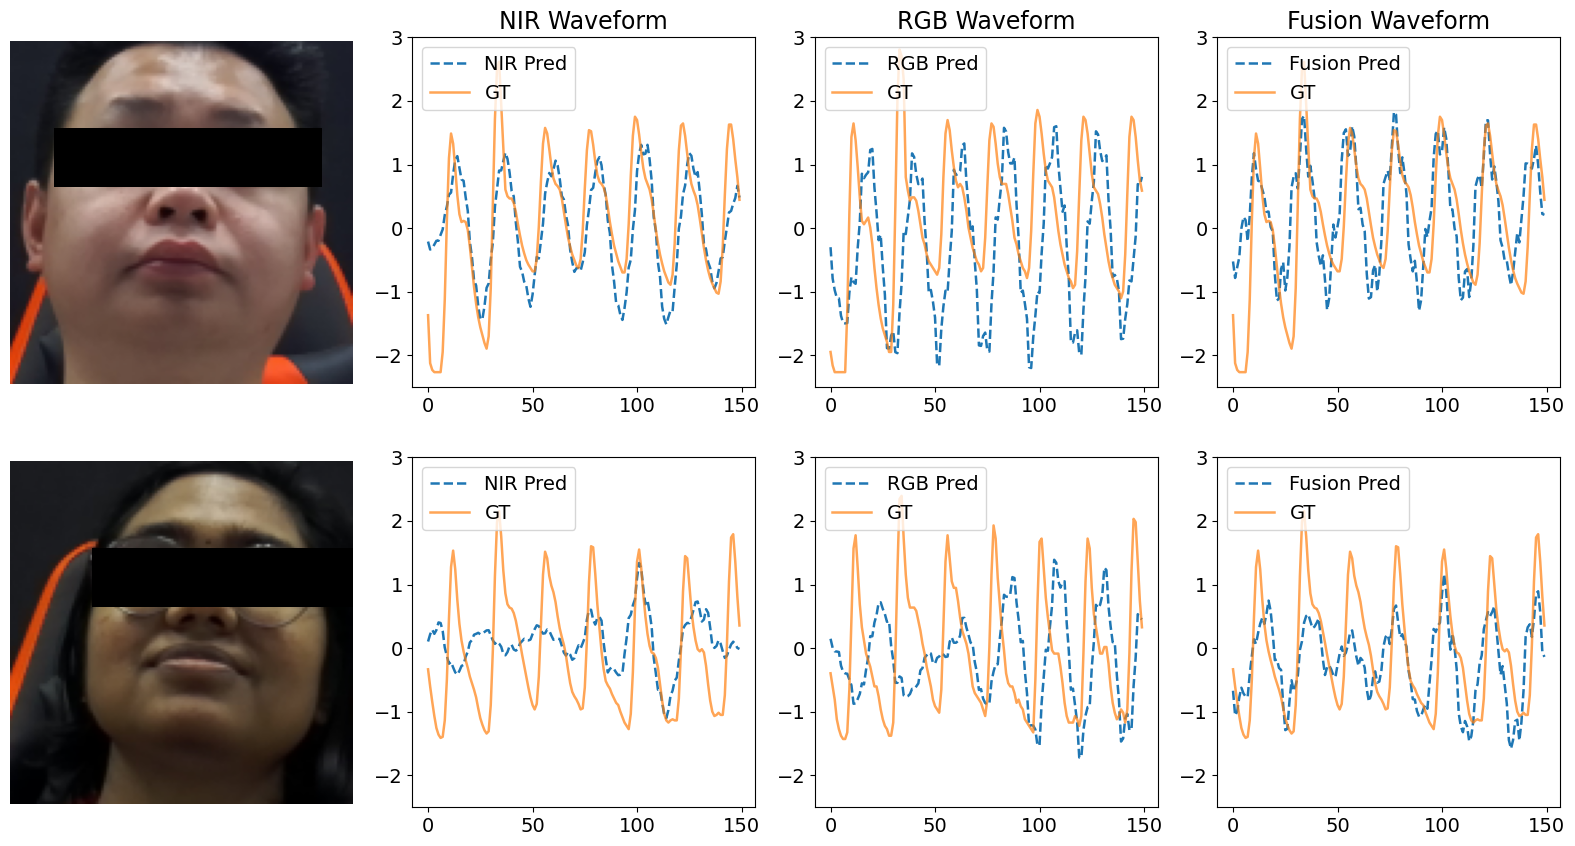

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
from matplotlib.patches import Rectangle


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

# --- Utility function to smooth a signal ---
def smooth_signal(signal, window_size=3):
    return np.convolve(signal, np.ones(window_size) / window_size, mode='same')

# --- Load a pickle file ---
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# --- Load a frame from .npy file ---
def load_frame(participant, chunk_idx):
    frame_path = f'/shared/ab227/CogPhys/chunked_dataset/{participant}/rgb_left_0.npy'
    array = np.load(frame_path)
    return array[0]  # first frame of chunk

# --- Define paths to data ---
fusion_path = '/home/dg73/CogPhys/waveforms/fusion_pre_nir/pred.pickle'
rgb_path = '/home/dg73/CogPhys/waveforms/rgb_cp+/pred.pickle'
nir_path = '/home/dg73/CogPhys/waveforms/nir_cp+_pre/pred.pickle'

# --- Load waveform data ---
fusion_data = load_pickle(fusion_path)
rgb_data = load_pickle(rgb_path)
nir_data = load_pickle(nir_path)

# --- Define 3 specific subjects to visualize ---
target_subjects = [
    ('v22_pattern', [0, 1, 2]),
    ('v37_read_rest', [0, 1, 2]),
    #('v32_still', [0, 1, 2])
]

# --- Create GridSpec figure with adjusted column spacing ---
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 1], wspace=0.175, hspace = 0.2)
axes = np.empty((2, 4), dtype=object)

# Assign axes from GridSpec
for row in range(2):
    for col in range(4):
        axes[row, col] = fig.add_subplot(gs[row, col])

for row, (participant, chunk_ids) in enumerate(target_subjects):
    key = (participant, chunk_ids)
    try:
        idx = fusion_data['participant_task_chunk_id_list'].index(key)
    except ValueError:
        print(f"Participant {key} not found.")
        continue

    # --- Frame ---
    frame = load_frame(participant, chunk_ids[0])
    axes[row, 0].imshow(frame)
    axes[row, 0].axis('off')
    
    if row==0:
        eye_bar = Rectangle(
        (16, 32),     # (x, y) coordinates — tweak as needed
        100,          # width of the bar (covers both eyes)
        22,           # height of the bar
        linewidth=0,
        edgecolor='none',
        facecolor='black'
        )
    elif row==1:
        eye_bar = Rectangle(
        (30, 32),     # (x, y) coordinates — tweak as needed
        100,          # width of the bar (covers both eyes)
        22,           # height of the bar
        linewidth=0,
        edgecolor='none',
        facecolor='black'
        )
    else:
        eye_bar = Rectangle(
        (8, 27),     # (x, y) coordinates — tweak as needed
        115,          # width of the bar (covers both eyes)
        22,           # height of the bar
        linewidth=0,
        edgecolor='none',
        facecolor='black'
        )
    
    # Add patch to the frame axis (leftmost column)
    axes[row, 0].add_patch(eye_bar)

    # --- NIR waveform ---
    nir_pred = smooth_signal(nir_data['pred'][idx][:150])
    nir_gt = smooth_signal(nir_data['gt'][idx][:150])
    axes[row, 1].plot(nir_pred, label='NIR Pred', linewidth=1.8, linestyle='--')
    axes[row, 1].plot(nir_gt, label='GT', linewidth=1.8, alpha=0.7)
    if row==0:
        axes[row, 1].set_title("NIR Waveform")
    axes[row, 1].legend(loc='upper left')
    axes[row, 1].set_ylim(-2.5, 3)


    # --- RGB waveform ---
    rgb_pred = rgb_data['pred'][idx][:150]
    rgb_gt = rgb_data['gt'][idx][:150]
    axes[row, 2].plot(rgb_pred, label='RGB Pred', linewidth=1.8, linestyle='--')
    axes[row, 2].plot(rgb_gt, label='GT', linewidth=1.8, alpha=0.7)
    if row==0:
        axes[row, 2].set_title("RGB Waveform")
    axes[row, 2].legend(loc='upper left')
    axes[row, 2].set_ylim(-2.5, 3)

    # --- Fusion waveform ---
    fusion_pred = smooth_signal(fusion_data['pred'][idx][:150])
    fusion_gt = smooth_signal(fusion_data['gt'][idx][:150])
    axes[row, 3].plot(fusion_pred, label='Fusion Pred', linewidth=1.8, linestyle='--')
    axes[row, 3].plot(fusion_gt, label='GT', linewidth=1.8, alpha=0.7)
    if row==0:
        axes[row, 3].set_title("Fusion Waveform")
    axes[row, 3].legend(loc='upper left')
    axes[row, 3].set_ylim(-2.5, 3)

plt.tight_layout()
plt.show()
